In [2]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Date and Time Handling
from datetime import datetime

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Feature Importance
from sklearn.inspection import permutation_importance

# Save Trained Models
import joblib

# Plot Settings
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


In [3]:
# Load and Combine the Dataset

# Read the CSV files
building_a = pd.read_csv("db_building_A.csv")
building_b = pd.read_csv("db_building_B.csv")

# Add a building identifier
building_a["Building"] = "A"
building_b["Building"] = "B"

# Combine both datasets
df = pd.concat([building_a, building_b], ignore_index=True)

# Display dataset information
print("Building A Shape:", building_a.shape)
print("Building B Shape:", building_b.shape)
print("Combined Dataset Shape:", df.shape)

# Display the first five rows
df.head()

Building A Shape: (43848, 13)
Building B Shape: (43848, 13)
Combined Dataset Shape: (87696, 13)


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,Building
0,1/1/2016 0:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
1,1/1/2016 1:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
2,1/1/2016 2:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
3,1/1/2016 3:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
4,1/1/2016 4:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A


In [4]:
# Dataset Exploration

# Display dataset shape
print("Dataset Shape:")
print(df.shape)

# Display first five records
print("\nFirst Five Records:")
display(df.head())

# Display last five records
print("\nLast Five Records:")
display(df.tail())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Display dataset information
print("\nDataset Information:")
df.info()

# Generate descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all').T)

# Display column names
print("\nColumn Names:")
for col in df.columns:
    print(col)

Dataset Shape:
(87696, 13)

First Five Records:


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,Building
0,1/1/2016 0:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
1,1/1/2016 1:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
2,1/1/2016 2:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
3,1/1/2016 3:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
4,1/1/2016 4:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A



Last Five Records:


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,Building
87691,12/31/2020 19:00,31.118,14.98,3.32,0.0,3.42,94.64,2.83,1.19,5.46,0.91,0,B
87692,12/31/2020 20:00,30.604,14.98,3.32,0.0,3.42,94.64,2.83,1.19,5.46,0.91,0,B
87693,12/31/2020 21:00,31.475,14.98,3.32,0.0,3.42,94.64,2.83,1.19,5.46,0.91,0,B
87694,12/31/2020 22:00,28.479,14.98,3.32,0.0,3.42,94.64,2.83,1.19,5.46,0.91,0,B
87695,12/31/2020 23:00,27.914,14.98,3.32,0.0,3.42,94.64,2.83,1.19,5.46,0.91,0,B



Data Types:
DATE         object
ENERGY      float64
HDD18_3     float64
CDD0        float64
CDD10       float64
PRECTOT     float64
RH2M        float64
T2M         float64
T2M_MIN     float64
T2M_MAX     float64
ALLSKY      float64
HOLIDAY       int64
Building     object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87696 entries, 0 to 87695
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DATE      87696 non-null  object 
 1   ENERGY    87527 non-null  float64
 2   HDD18_3   87696 non-null  float64
 3   CDD0      87696 non-null  float64
 4   CDD10     87696 non-null  float64
 5   PRECTOT   87696 non-null  float64
 6   RH2M      87696 non-null  float64
 7   T2M       87696 non-null  float64
 8   T2M_MIN   87696 non-null  float64
 9   T2M_MAX   87696 non-null  float64
 10  ALLSKY    87408 non-null  float64
 11  HOLIDAY   87696 non-null  int64  
 12  Building  87696 non-null  objec

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE,87696,43845,10/27/2019 3:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENERGY,87527.0,NaN,NaN,NaN,116.087789,77.997324,5.647,49.751,112.727,141.507,469.756
HDD18_3,87696.0,NaN,NaN,NaN,6.36529,5.536038,0.0,0.0,6.19,11.26,19.69
CDD0,87696.0,NaN,NaN,NaN,13.011179,6.996814,0.0,7.04,12.11,19.04,29.01
CDD10,87696.0,NaN,NaN,NaN,4.604367,5.303695,0.0,0.0,2.11,9.04,19.01
PRECTOT,87696.0,NaN,NaN,NaN,1.366969,3.065255,0.0,0.0,0.08,1.28,46.17
RH2M,87696.0,NaN,NaN,NaN,65.738516,17.283634,24.09,51.65,65.89,80.89,100.0
T2M,87696.0,NaN,NaN,NaN,12.510298,7.263247,-2.62,6.39,11.71,18.67,28.63
T2M_MIN,87696.0,NaN,NaN,NaN,6.861143,5.87805,-5.86,2.2,6.43,11.68,20.96
T2M_MAX,87696.0,NaN,NaN,NaN,19.157221,8.466483,2.76,12.03,18.17,26.27,38.66



Column Names:
DATE
ENERGY
HDD18_3
CDD0
CDD10
PRECTOT
RH2M
T2M
T2M_MIN
T2M_MAX
ALLSKY
HOLIDAY
Building


In [5]:
# Data Preprocessing

# -------------------------------
# Check Missing Values
# -------------------------------
print("Missing Values:")
print(df.isnull().sum())

# -------------------------------
# Handle Missing Values
# -------------------------------
# Fill missing ENERGY values using forward fill
df["ENERGY"] = df["ENERGY"].fillna(method="ffill")

# Fill missing ALLSKY values using median
df["ALLSKY"] = df["ALLSKY"].fillna(df["ALLSKY"].median())

# Verify missing values
print("\nMissing Values After Treatment:")
print(df.isnull().sum())

# -------------------------------
# Check Duplicate Records
# -------------------------------
duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Records:", duplicates)

# -------------------------------
# Remove Duplicate Records
# -------------------------------
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

# -------------------------------
# Convert Date and Time Column
# -------------------------------
df["DATE"] = pd.to_datetime(df["DATE"])

print("\nDATE column converted successfully.")

# -------------------------------
# Check Data Types
# -------------------------------
print("\nUpdated Data Types:")
print(df.dtypes)

# Display first five rows
df.head()

Missing Values:
DATE          0
ENERGY      169
HDD18_3       0
CDD0          0
CDD10         0
PRECTOT       0
RH2M          0
T2M           0
T2M_MIN       0
T2M_MAX       0
ALLSKY      288
HOLIDAY       0
Building      0
dtype: int64

Missing Values After Treatment:
DATE        0
ENERGY      1
HDD18_3     0
CDD0        0
CDD10       0
PRECTOT     0
RH2M        0
T2M         0
T2M_MIN     0
T2M_MAX     0
ALLSKY      0
HOLIDAY     0
Building    0
dtype: int64

Number of Duplicate Records: 0
Dataset Shape After Removing Duplicates: (87696, 13)

DATE column converted successfully.

Updated Data Types:
DATE        datetime64[ns]
ENERGY             float64
HDD18_3            float64
CDD0               float64
CDD10              float64
PRECTOT            float64
RH2M               float64
T2M                float64
T2M_MIN            float64
T2M_MAX            float64
ALLSKY             float64
HOLIDAY              int64
Building            object
dtype: object


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,Building
0,2016-01-01 00:00:00,NaN,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
1,2016-01-01 01:00:00,113.415,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
2,2016-01-01 02:00:00,112.431,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
3,2016-01-01 03:00:00,111.517,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A
4,2016-01-01 04:00:00,117.240,11.32,6.98,0.0,10.7,90.97,6.02,1.74,12.23,1.7,1,A


In [6]:
# Feature Engineering

# Fill the remaining missing ENERGY value
df["ENERGY"] = df["ENERGY"].bfill()

# -------------------------------
# Create Time-Based Features
# -------------------------------

# Hour
df["Hour"] = df["DATE"].dt.hour

# Day
df["Day"] = df["DATE"].dt.day

# Month
df["Month"] = df["DATE"].dt.month

# Weekday (Monday=0, Sunday=6)
df["Weekday"] = df["DATE"].dt.weekday

# Weekend Indicator
df["Weekend"] = df["Weekday"].apply(lambda x: 1 if x >= 5 else 0)

# Year
df["Year"] = df["DATE"].dt.year

# -------------------------------
# Create Lag Features
# -------------------------------

# Previous hour energy consumption
df["Lag_1"] = df["ENERGY"].shift(1)

# Previous 24-hour energy consumption
df["Lag_24"] = df["ENERGY"].shift(24)

# Previous one week (168 hours)
df["Lag_168"] = df["ENERGY"].shift(168)

# -------------------------------
# Create Rolling Mean Features
# -------------------------------

# Rolling Mean (Previous 24 Hours)
df["Rolling_Mean_24"] = df["ENERGY"].rolling(window=24).mean()

# Rolling Mean (Previous 7 Days = 168 Hours)
df["Rolling_Mean_168"] = df["ENERGY"].rolling(window=168).mean()

# -------------------------------
# Remove rows with missing values
# (Generated due to lag and rolling features)
# -------------------------------

df = df.dropna().reset_index(drop=True)

# -------------------------------
# Display Results
# -------------------------------

print("Dataset Shape After Feature Engineering:", df.shape)

df.head()

Dataset Shape After Feature Engineering: (87528, 24)


,DATE,ENERGY,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,...,Day,Month,Weekday,Weekend,Year,Lag_1,Lag_24,Lag_168,Rolling_Mean_24,Rolling_Mean_168
0,2016-01-08 00:00:00,130.526,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,...,8,1,4,0,2016,131.035,119.208,113.415,198.828000,131.988024
1,2016-01-08 01:00:00,133.645,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,...,8,1,4,0,2016,130.526,120.027,113.415,199.395417,132.108440
2,2016-01-08 02:00:00,135.460,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,...,8,1,4,0,2016,133.645,122.728,112.431,199.925917,132.245518
3,2016-01-08 03:00:00,137.595,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,...,8,1,4,0,2016,135.460,128.337,111.517,200.311667,132.400744
4,2016-01-08 04:00:00,143.414,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,...,8,1,4,0,2016,137.595,131.244,117.240,200.818750,132.556542


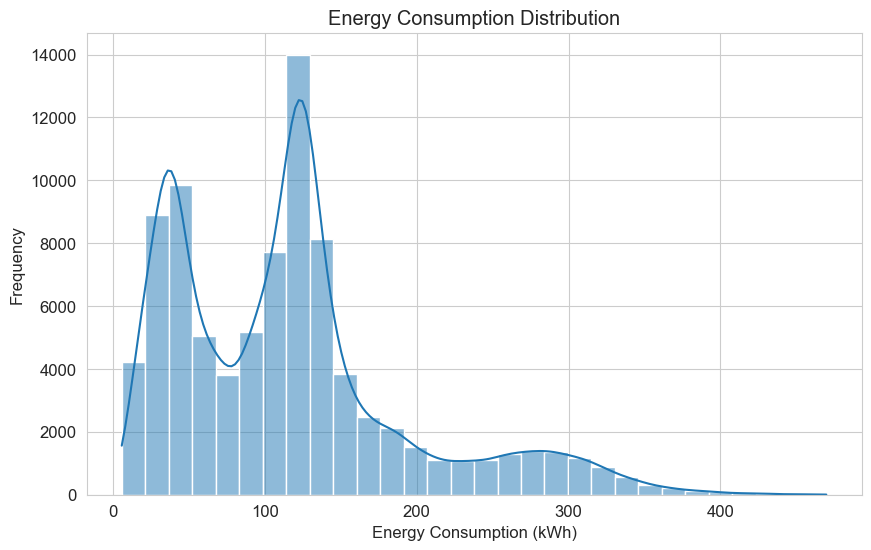

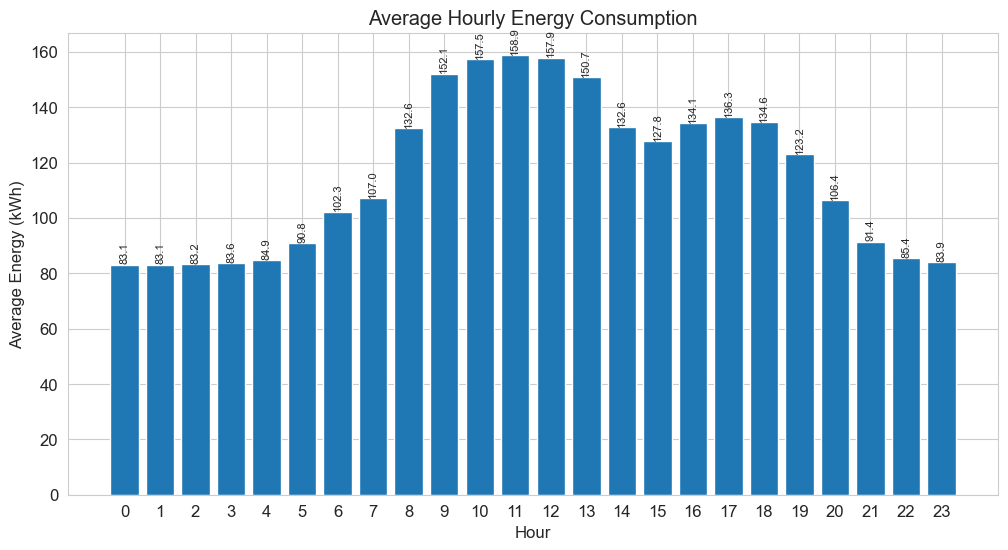

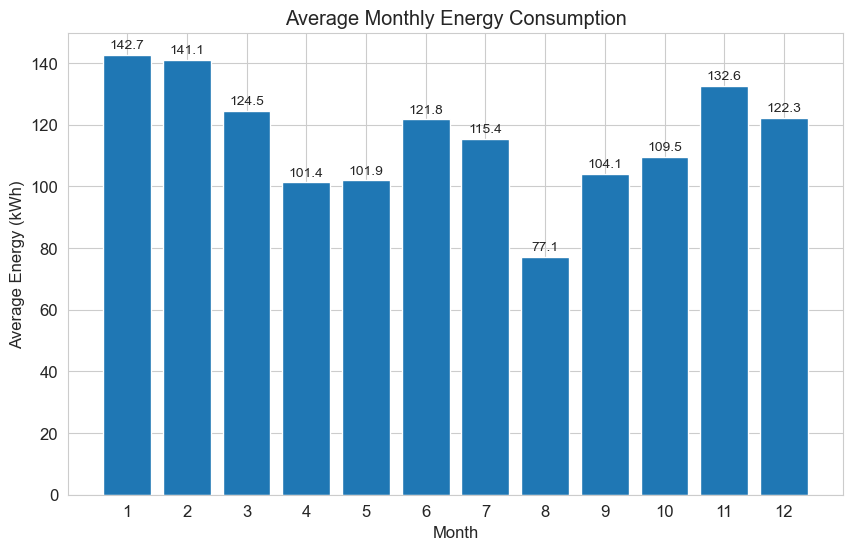

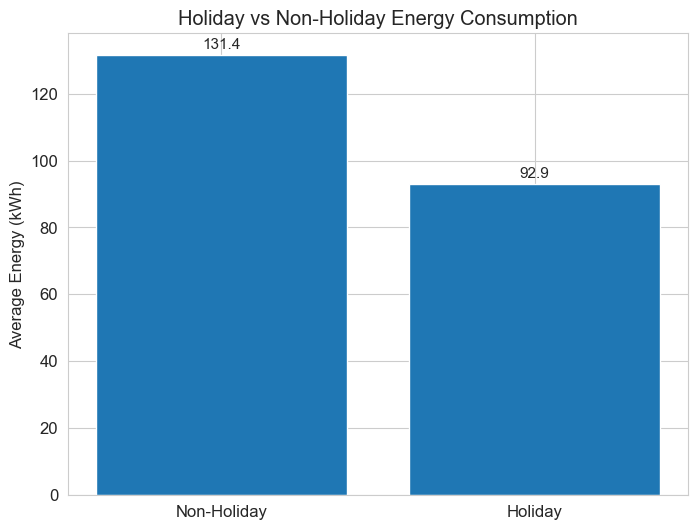

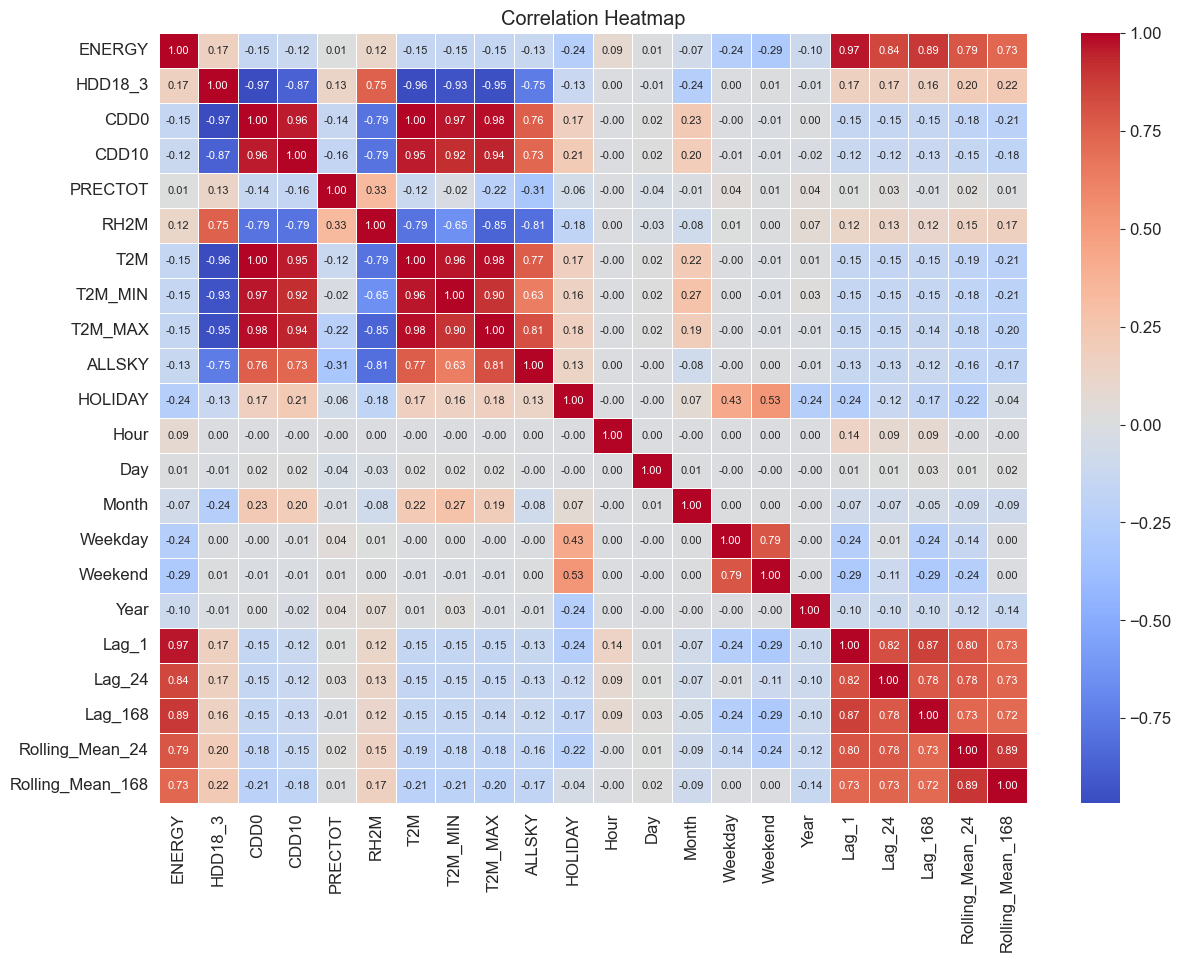

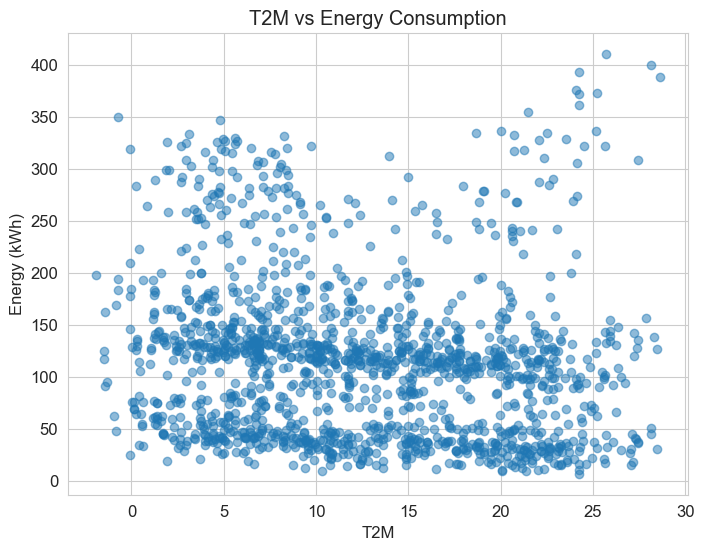

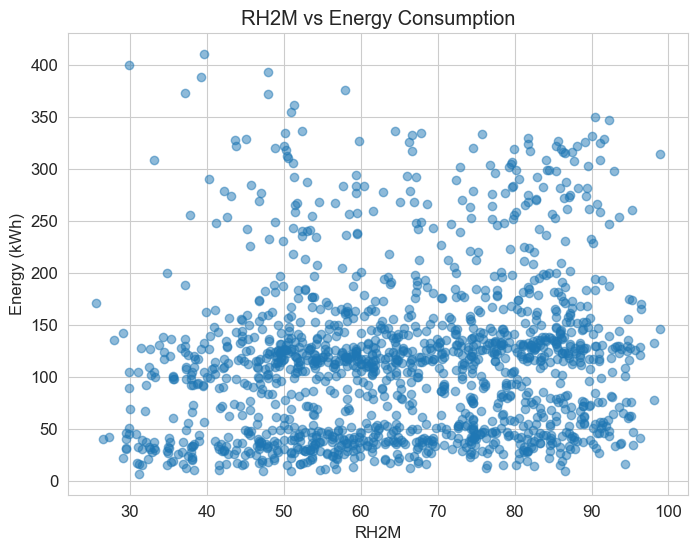

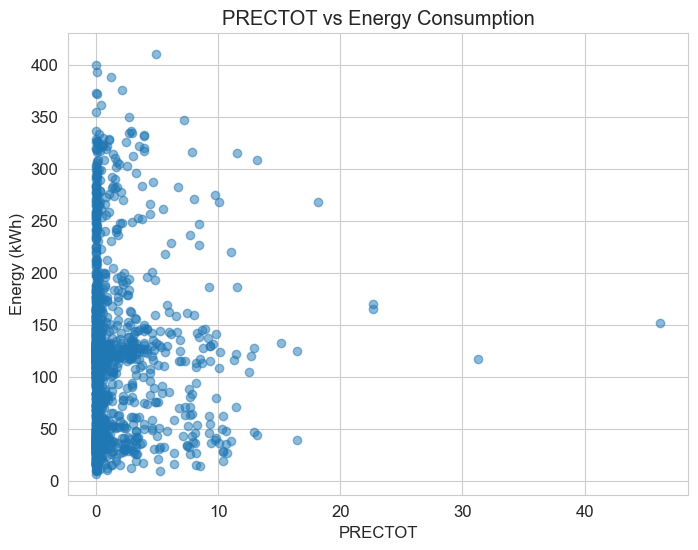

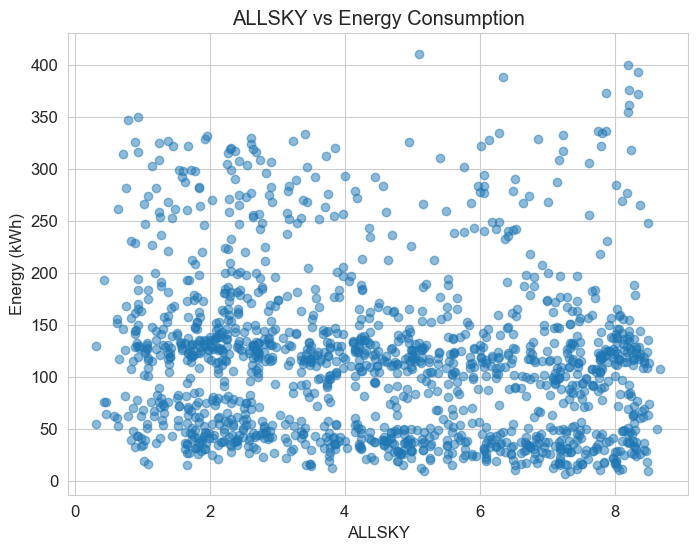

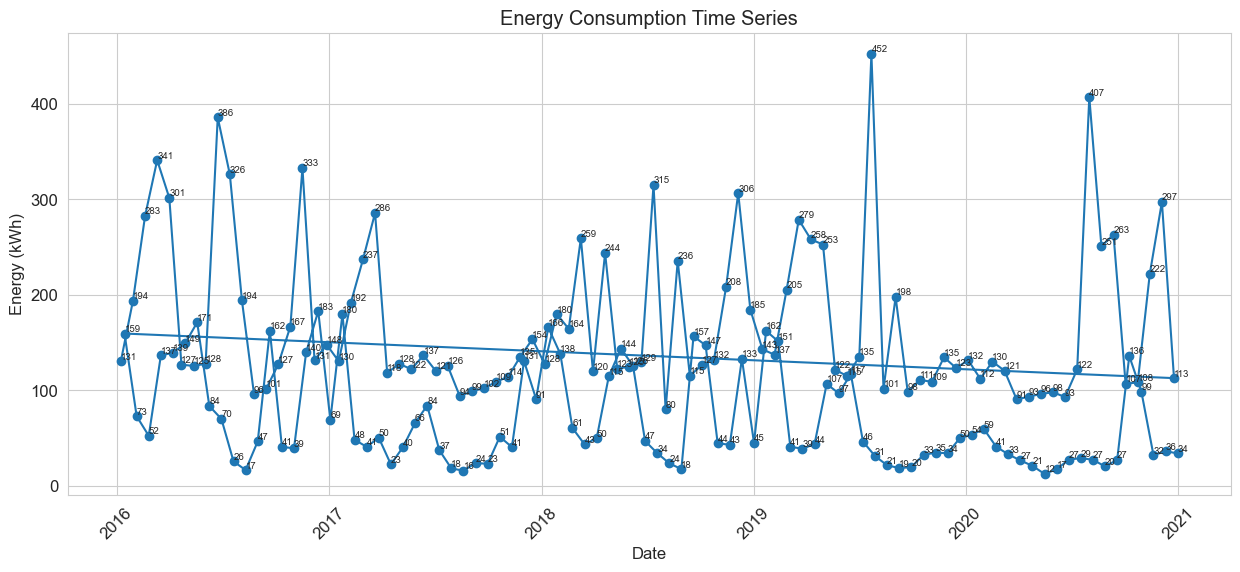

In [11]:
# Exploratory Data Analysis (EDA)

plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# 1. Energy Distribution

plt.figure(figsize=(10,6))
sns.histplot(df["ENERGY"], bins=30, kde=True)

plt.title("Energy Consumption Distribution")
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.show()


# 2. Hourly Average Energy Consumption

hourly = df.groupby("Hour")["ENERGY"].mean()

plt.figure(figsize=(12,6))

bars = plt.bar(hourly.index.astype(str), hourly.values)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f'{bar.get_height():.1f}',
             ha='center',
             fontsize=8,
             rotation=90)

plt.title("Average Hourly Energy Consumption")
plt.xlabel("Hour")
plt.ylabel("Average Energy (kWh)")

plt.show()


# 3. Monthly Average Energy Consumption

monthly = df.groupby("Month")["ENERGY"].mean()

plt.figure(figsize=(10,6))

bars = plt.bar(monthly.index.astype(str), monthly.values)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+2,
             f'{bar.get_height():.1f}',
             ha='center',
             fontsize=10)

plt.title("Average Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Average Energy (kWh)")

plt.show()


# 4. Holiday vs Non-Holiday

holiday = df.groupby("HOLIDAY")["ENERGY"].mean()

plt.figure(figsize=(8,6))

bars = plt.bar(["Non-Holiday","Holiday"], holiday.values)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+2,
             f'{bar.get_height():.1f}',
             ha='center',
             fontsize=11)

plt.title("Holiday vs Non-Holiday Energy Consumption")
plt.ylabel("Average Energy (kWh)")

plt.show()


# 5. Correlation Heatmap

plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.title("Correlation Heatmap")

plt.show()


# 6. Weather Variable Relationships

weather = ["T2M","RH2M","PRECTOT","ALLSKY"]

for var in weather:

    sample = df.sample(1500, random_state=42)

    plt.figure(figsize=(8,6))

    plt.scatter(sample[var], sample["ENERGY"], alpha=0.5)

    plt.title(f"{var} vs Energy Consumption")
    plt.xlabel(var)
    plt.ylabel("Energy (kWh)")

    plt.show()


# 7. Energy Consumption Time Series

sample = df.iloc[::500]

plt.figure(figsize=(15,6))

plt.plot(sample["DATE"], sample["ENERGY"], marker='o')

for x,y in zip(sample["DATE"], sample["ENERGY"]):
    plt.text(x,y+2,f'{y:.0f}',fontsize=7)

plt.title("Energy Consumption Time Series")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")

plt.xticks(rotation=45)

plt.show()

In [12]:
# Step 7: Feature Selection

# Encode the Building column
df["Building"] = df["Building"].map({"A": 0, "B": 1})

# Define the independent variables (X)
X = df.drop(columns=["DATE", "ENERGY"])

# Define the target variable (y)
y = df["ENERGY"]

# Display information
print("Independent Variables (X):")
print(X.columns.tolist())

print("\nTarget Variable (y):")
print(y.name)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Display first five rows
print("\nIndependent Variables (First Five Rows):")
display(X.head())

print("\nTarget Variable (First Five Rows):")
display(y.head())

Independent Variables (X):
['HDD18_3', 'CDD0', 'CDD10', 'PRECTOT', 'RH2M', 'T2M', 'T2M_MIN', 'T2M_MAX', 'ALLSKY', 'HOLIDAY', 'Building', 'Hour', 'Day', 'Month', 'Weekday', 'Weekend', 'Year', 'Lag_1', 'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Mean_168']

Target Variable (y):
ENERGY

Shape of X: (87528, 22)
Shape of y: (87528,)

Independent Variables (First Five Rows):


,HDD18_3,CDD0,CDD10,PRECTOT,RH2M,T2M,T2M_MIN,T2M_MAX,ALLSKY,HOLIDAY,...,Day,Month,Weekday,Weekend,Year,Lag_1,Lag_24,Lag_168,Rolling_Mean_24,Rolling_Mean_168
0,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,0.96,0,...,8,1,4,0,2016,131.035,119.208,113.415,198.828000,131.988024
1,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,0.96,0,...,8,1,4,0,2016,130.526,120.027,113.415,199.395417,132.108440
2,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,0.96,0,...,8,1,4,0,2016,133.645,122.728,112.431,199.925917,132.245518
3,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,0.96,0,...,8,1,4,0,2016,135.460,128.337,111.517,200.311667,132.400744
4,8.16,10.14,0.14,9.61,90.28,10.13,8.08,12.2,0.96,0,...,8,1,4,0,2016,137.595,131.244,117.240,200.818750,132.556542



Target Variable (First Five Rows):


0    130.526
1    133.645
2    135.460
3    137.595
4    143.414
Name: ENERGY, dtype: float64

In [13]:
# Train-Test Split

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False,
    random_state=42
)

# Display dataset sizes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Target Shape  :", y_train.shape)
print("Testing Target Shape   :", y_test.shape)

Training Features Shape: (70022, 22)
Testing Features Shape : (17506, 22)
Training Target Shape  : (70022,)
Testing Target Shape   : (17506,)


In [14]:
# Machine Learning Model Development

# Feature Scaling (Required for ANN)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# inear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully.")

# Random Forest Regression

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression Model Trained Successfully.")

# Gradient Boosting Regression

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Regression Model Trained Successfully.")

# XGBoost Regression

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Regression Model Trained Successfully.")

# Artificial Neural Network (ANN)

ann_model = MLPRegressor(
    hidden_layer_sizes=(100,50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train)

y_pred_ann = ann_model.predict(X_test_scaled)

print("Artificial Neural Network Model Trained Successfully.")

print("\nAll Machine Learning Models have been developed and predictions generated successfully.")

Linear Regression Model Trained Successfully.
Random Forest Regression Model Trained Successfully.
Gradient Boosting Regression Model Trained Successfully.
XGBoost Regression Model Trained Successfully.
Artificial Neural Network Model Trained Successfully.

All Machine Learning Models have been developed and predictions generated successfully.


In [15]:
# Model Performance Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np
import pandas as pd

# Function to calculate evaluation metrics
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    return [mae, rmse, mape, r2]

# Calculate metrics for each model
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "Artificial Neural Network"
    ],
    "MAE": [
        evaluate_model(y_test, y_pred_lr)[0],
        evaluate_model(y_test, y_pred_rf)[0],
        evaluate_model(y_test, y_pred_gb)[0],
        evaluate_model(y_test, y_pred_xgb)[0],
        evaluate_model(y_test, y_pred_ann)[0]
    ],
    "RMSE": [
        evaluate_model(y_test, y_pred_lr)[1],
        evaluate_model(y_test, y_pred_rf)[1],
        evaluate_model(y_test, y_pred_gb)[1],
        evaluate_model(y_test, y_pred_xgb)[1],
        evaluate_model(y_test, y_pred_ann)[1]
    ],
    "MAPE (%)": [
        evaluate_model(y_test, y_pred_lr)[2],
        evaluate_model(y_test, y_pred_rf)[2],
        evaluate_model(y_test, y_pred_gb)[2],
        evaluate_model(y_test, y_pred_xgb)[2],
        evaluate_model(y_test, y_pred_ann)[2]
    ],
    "R² Score": [
        evaluate_model(y_test, y_pred_lr)[3],
        evaluate_model(y_test, y_pred_rf)[3],
        evaluate_model(y_test, y_pred_gb)[3],
        evaluate_model(y_test, y_pred_xgb)[3],
        evaluate_model(y_test, y_pred_ann)[3]
    ]
})

# Round the results
results = results.round(4)

# Display the evaluation results
print("Model Performance Comparison")
display(results)

Model Performance Comparison


,Model,MAE,RMSE,MAPE (%),R² Score
0,Linear Regression,7.8969,10.5635,19.4686,0.9253
1,Random Forest,4.7370,7.2198,11.9230,0.9651
2,Gradient Boosting,6.4459,8.9923,19.5553,0.9459
3,XGBoost,4.7138,6.8152,13.2215,0.9689
4,Artificial Neural Network,6.1018,8.4707,16.9453,0.9520


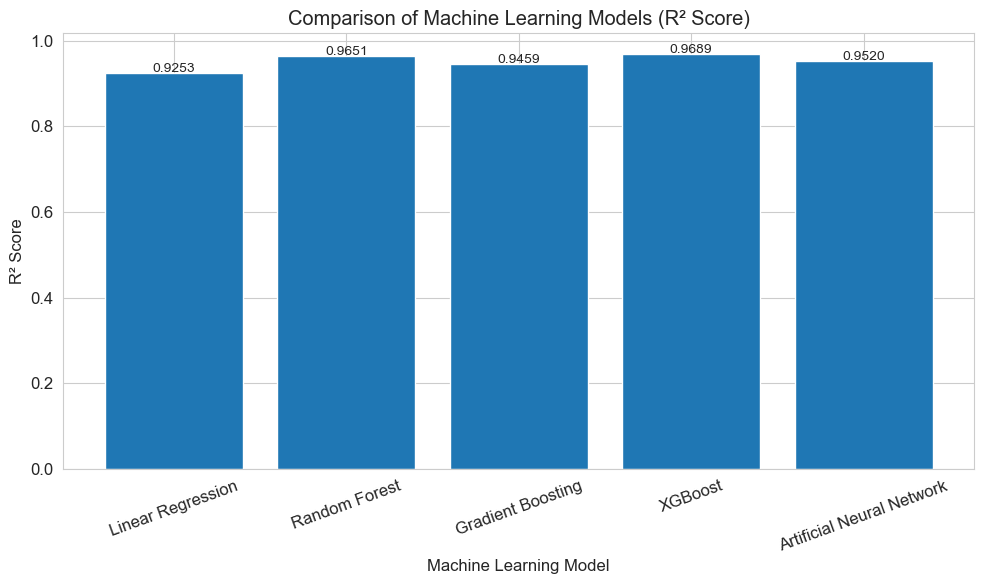

In [16]:
# Visual Comparison of R² Scores

plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["R² Score"])

plt.title("Comparison of Machine Learning Models (R² Score)")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Random Forest Feature Importance


,Feature,Importance
0,Lag_1,0.921883
1,Lag_24,0.025603
2,Hour,0.017024
3,Lag_168,0.014590
4,Rolling_Mean_24,0.002584
5,T2M_MIN,0.002316
6,Rolling_Mean_168,0.002028
7,Weekday,0.001633
8,T2M,0.001607
9,ALLSKY,0.001348


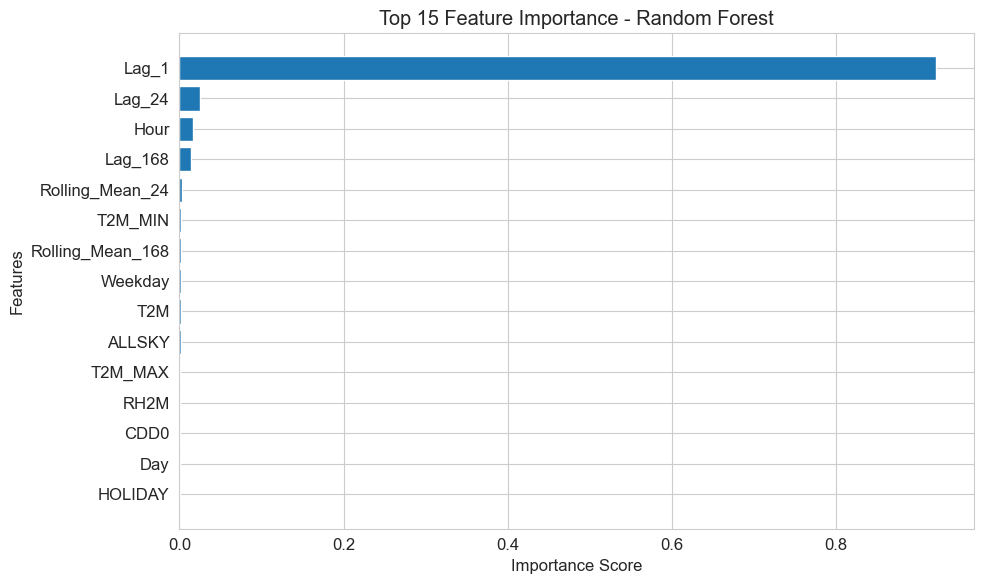

XGBoost Feature Importance


,Feature,Importance
0,Lag_1,0.843447
1,Lag_24,0.025345
2,Lag_168,0.021968
3,Hour,0.019029
4,T2M,0.013698
5,Weekday,0.012499
6,CDD10,0.010754
7,HOLIDAY,0.009811
8,T2M_MIN,0.007611
9,Building,0.005653


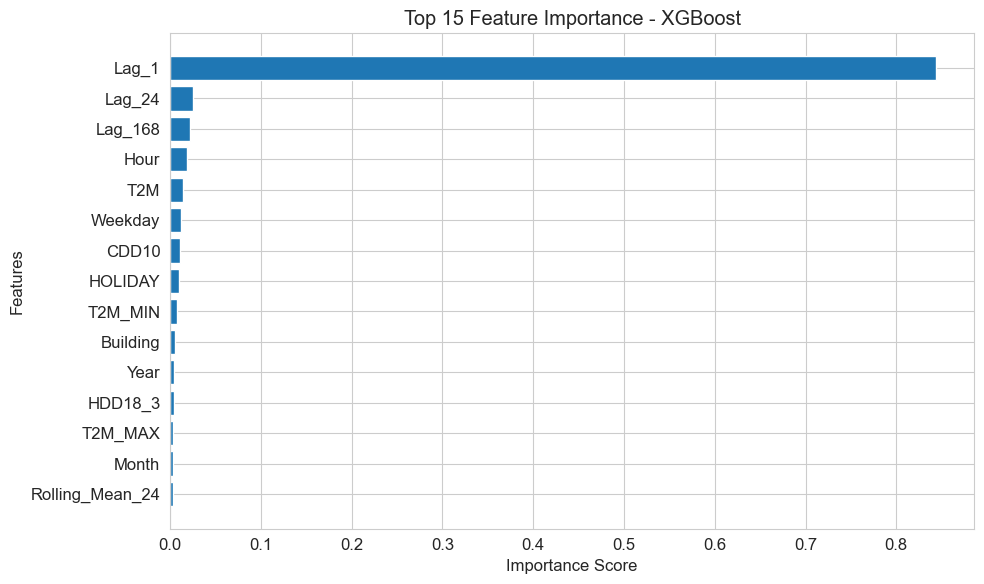

Overall Feature Ranking


,Feature,Importance_RF,Importance_XGB,Average Importance
0,Lag_1,0.921883,0.843447,0.882665
1,Lag_24,0.025603,0.025345,0.025474
2,Lag_168,0.014590,0.021968,0.018279
3,Hour,0.017024,0.019029,0.018026
4,T2M,0.001607,0.013698,0.007653
5,Weekday,0.001633,0.012499,0.007066
6,CDD10,0.000847,0.010754,0.005800
7,HOLIDAY,0.000886,0.009811,0.005348
8,T2M_MIN,0.002316,0.007611,0.004963
9,Building,0.000122,0.005653,0.002888


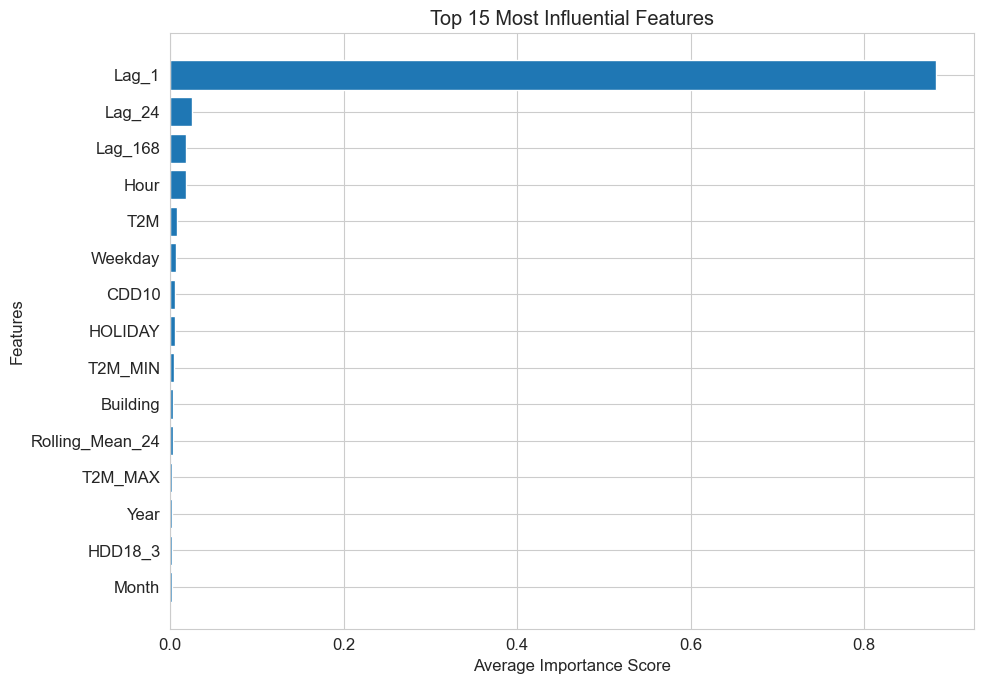

In [17]:
# Feature Importance Analysis

# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance")
display(rf_importance)

plt.figure(figsize=(10,6))

plt.barh(
    rf_importance["Feature"][:15],
    rf_importance["Importance"][:15]
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("XGBoost Feature Importance")
display(xgb_importance)

plt.figure(figsize=(10,6))

plt.barh(
    xgb_importance["Feature"][:15],
    xgb_importance["Importance"][:15]
)

plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Combined Feature Importance Ranking

feature_ranking = pd.merge(
    rf_importance,
    xgb_importance,
    on="Feature",
    suffixes=("_RF", "_XGB")
)

feature_ranking["Average Importance"] = (
    feature_ranking["Importance_RF"] +
    feature_ranking["Importance_XGB"]
) / 2

feature_ranking = feature_ranking.sort_values(
    by="Average Importance",
    ascending=False
).reset_index(drop=True)

print("Overall Feature Ranking")
display(feature_ranking)

plt.figure(figsize=(10,7))

plt.barh(
    feature_ranking["Feature"][:15],
    feature_ranking["Average Importance"][:15]
)

plt.title("Top 15 Most Influential Features")
plt.xlabel("Average Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# Identify the Best Performing Model
# ============================================================

best_model = results.sort_values(
    by=["R² Score", "RMSE"],
    ascending=[False, True]
).iloc[0]

print("Best Model:", best_model["Model"])

Best Model: XGBoost


Best Model: XGBoost


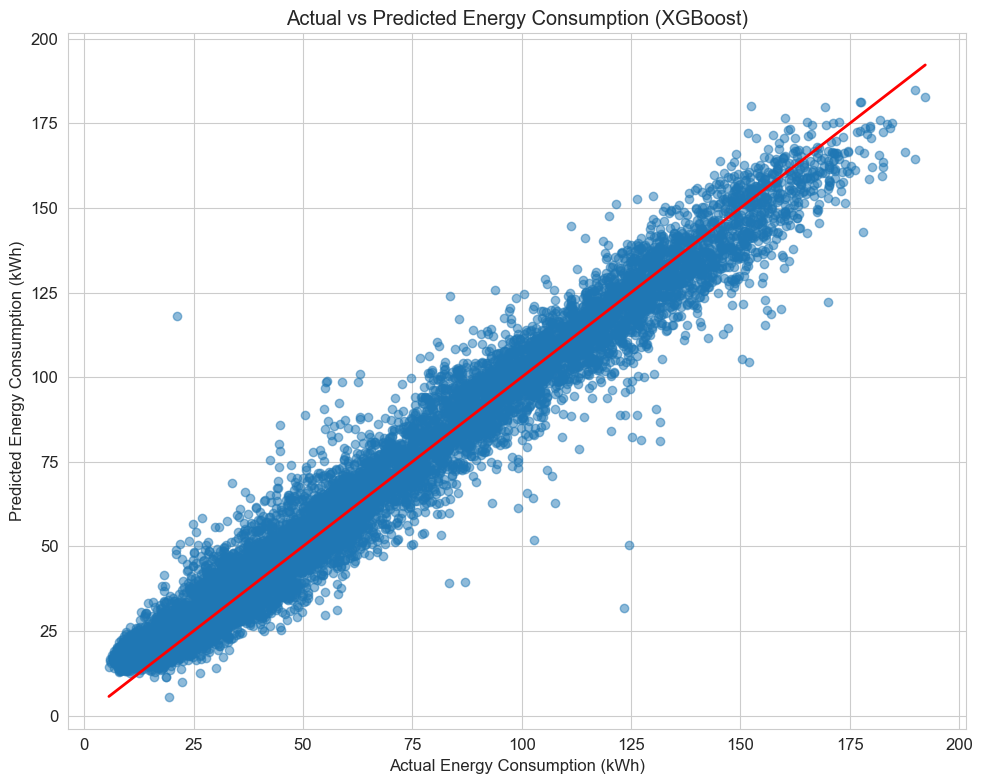

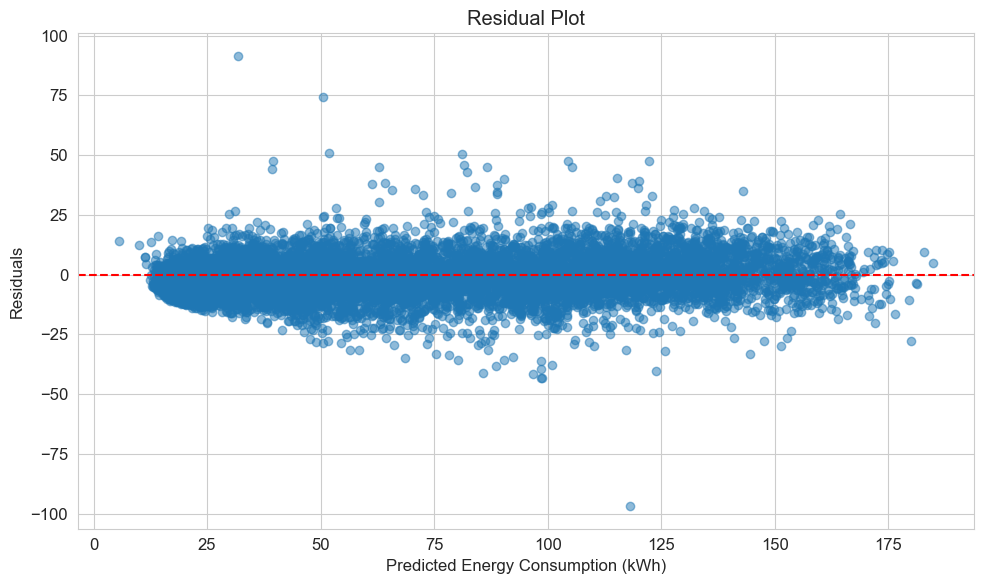

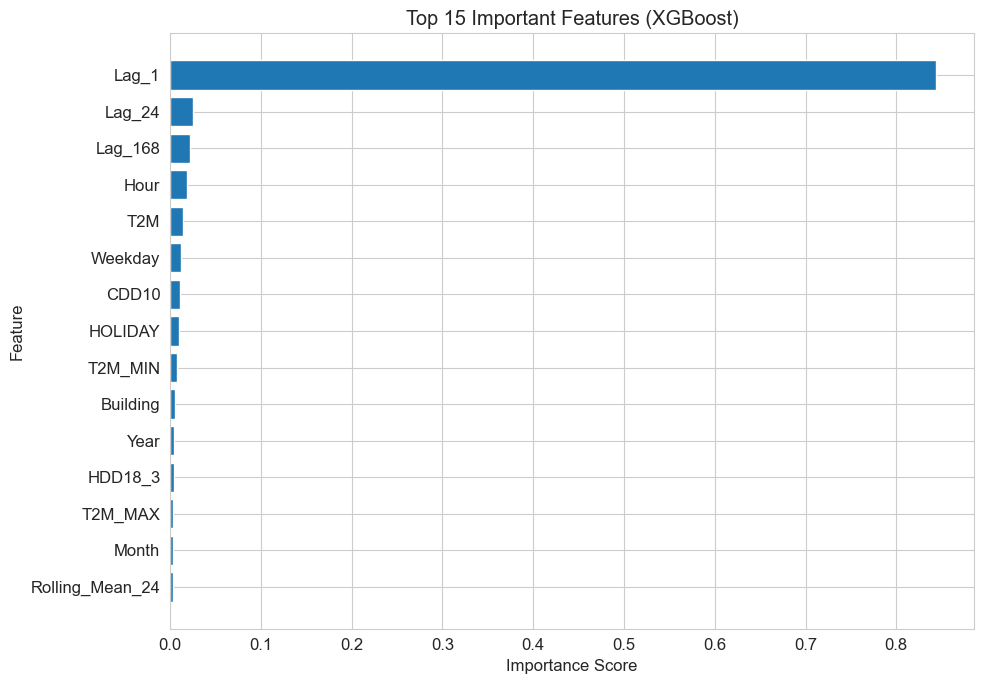

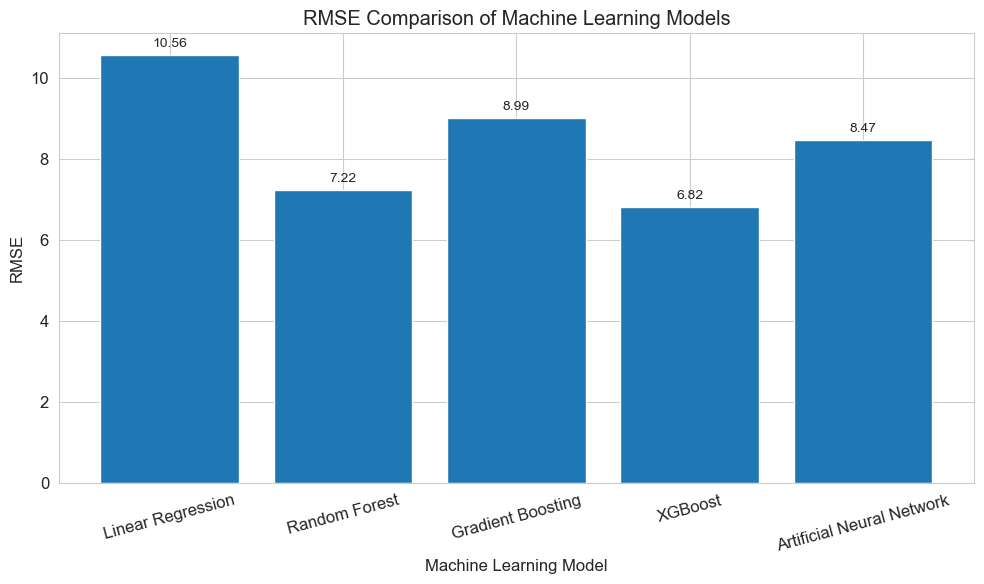

Prediction visualizations generated successfully.


In [21]:
# Prediction Visualization

# Select the Best Model Predictions

if best_model["Model"] == "Linear Regression":
    y_pred = y_pred_lr
elif best_model["Model"] == "Random Forest":
    y_pred = y_pred_rf
elif best_model["Model"] == "Gradient Boosting":
    y_pred = y_pred_gb
elif best_model["Model"] == "XGBoost":
    y_pred = y_pred_xgb
else:
    y_pred = y_pred_ann

# Actual vs Predicted Values

plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title(f"Actual vs Predicted Energy Consumption ({best_model['Model']})")
plt.xlabel("Actual Energy Consumption (kWh)")
plt.ylabel("Predicted Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Energy Consumption (kWh)")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

# Feature Importance Plot
# (Best Tree-Based Model)

if best_model["Model"] == "Random Forest":

    importance = rf_importance

elif best_model["Model"] == "XGBoost":

    importance = xgb_importance

else:

    importance = feature_ranking.rename(
        columns={"Average Importance":"Importance"}
    )[["Feature","Importance"]]

plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title(f"Top 15 Important Features ({best_model['Model']})")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Error Comparison Bar Chart

plt.figure(figsize=(10,6))

bars = plt.bar(results["Model"], results["RMSE"])

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.2,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10
    )

plt.title("RMSE Comparison of Machine Learning Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

print("Prediction visualizations generated successfully.")

In [22]:
# Save the Best Model

# Select the best model
if best_model["Model"] == "Linear Regression":
    final_model = lr_model
    model_name = "Linear_Regression_Model.pkl"

elif best_model["Model"] == "Random Forest":
    final_model = rf_model
    model_name = "Random_Forest_Model.pkl"

elif best_model["Model"] == "Gradient Boosting":
    final_model = gb_model
    model_name = "Gradient_Boosting_Model.pkl"

elif best_model["Model"] == "XGBoost":
    final_model = xgb_model
    model_name = "XGBoost_Model.pkl"

else:
    final_model = ann_model
    model_name = "ANN_Model.pkl"

# Save the model
joblib.dump(final_model, model_name)

print(f"Best model ({best_model['Model']}) has been saved successfully.")
print(f"Filename: {model_name}")

Best model (XGBoost) has been saved successfully.
Filename: XGBoost_Model.pkl
